# Exploring the Alignment Tax: Temperature Dynamics, Divergent Thinking, and Mode Collapse in Large Language Models

### Abstract
Reinforcement Learning from Human Feedback (RLHF) optimizes language models for helpfulness and safety, but frequently penalizes the stochastic tail of token distributions where conceptual novelty resides—a phenomenon known as the **Alignment Tax** or **Mode Collapse**. 

This research project presents an empirical investigation into the dynamics of temperature sampling ($T \in [0.0, 1.5]$) on generative creativity and epistemic diversity. Using Guilford's **Alternative Uses Task (AUT)** across standardized object domains, we evaluate model outputs using a dual-modality framework:
1. **Multi-Dimensional Human Psychometric Rubric:** Originality, Context Specificity, and Domain Abstraction.
2. **Computational NLP Diversity Metrics:** Lexical Type-Token Ratios (TTR) and Dense Embedding Pairwise Cosine Distance (`all-MiniLM-L6-v2`).
3. **Statistical Mode Collapse Detection:** Asynchronous multi-trial repetition testing paired with exact-match deduplication and Binomial hypothesis testing on high-similarity semantic clusters ($\text{Cosine Similarity} > 0.85$).

In [ ]:
# Environment Setup

import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from google import genai
from google.genai import types
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity

# Initialize plotting parameters
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Initialize client using environment credentials
API_KEY = os.getenv("GEMINI_API_KEY") or os.getenv("OPENAI_API_KEY")
client = genai.Client(api_key=API_KEY)

# Load dense sentence embedding model for semantic diversity & similarity benchmarks
embedder = SentenceTransformer('all-MiniLM-L6-v2')

## 1. The Divergent Thinking Experiment

I evaluated divergent thinking using the Alternative Uses Task across:
* **Objects ($n=3$):** `spectacles`, `socks`, `flower` (representing distinct functional, tactile, and biological affordances).
* **Temperature Grid ($n=5$):** $T \in \{0.0, 0.3, 0.7, 1.0, 1.5\}$ (spanning greedy argmax decoding to hyper-stochastic sampling).
* **Generation Volume:** 20 unique uses per object-temperature condition ($3 \times 5 \times 20 = 300$ candidate generations).

In [ ]:
# Run the divergent thinking experiment across temperatures

objects = ['spectacles', 'socks', 'flower']
temperatures = [0.0, 0.3, 0.7, 1.0, 1.5]

divergent_thinking_results = [] 

for obj in objects:
    for temp in temperatures:
        print(f"Running for object: {obj}, temperature: {temp}")

        config = types.GenerateContentConfig(
            temperature=temp
        )

        prompt = f"List 20 unusual uses for a {obj}. Be creative and surprising. Number each use.\n"

        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents = prompt,
                config=config
                )

            # Extract uses. The model tends to number them, so i split by newline and check for numbers.
            uses = [use.strip() for use in response.text.strip().split('\n') if use.strip() and use[0].isdigit()]

            for i, use in enumerate(uses):
                divergent_thinking_results.append({
                    'object': obj,
                    'temperature': temp,
                    'use_number': i + 1,
                    'use_description': use
                })

            # Add a small delay to avoid hitting API rate limits
            time.sleep(1)

        except Exception as e:
            print(f"Error generating content for {obj} at temperature {temp}: {e}")

# Convert results to a DataFrame for easier analysis
df_divergent_thinking = pd.DataFrame(divergent_thinking_results)

print("Divergent thinking experiment complete. Here are the first few results:")
display(df_divergent_thinking.head())

# remember to update the store so i dont keep re-running and running out of tokens CRY
store1 = df_divergent_thinking

Running for object: spectacles, temperature: 0.0
Running for object: spectacles, temperature: 0.3
Running for object: spectacles, temperature: 0.7
Running for object: spectacles, temperature: 1.0
Running for object: spectacles, temperature: 1.5
Running for object: socks, temperature: 0.0
Running for object: socks, temperature: 0.3
Running for object: socks, temperature: 0.7
Running for object: socks, temperature: 1.0
Running for object: socks, temperature: 1.5
Running for object: flower, temperature: 0.0
Running for object: flower, temperature: 0.3
Running for object: flower, temperature: 0.7
Running for object: flower, temperature: 1.0
Running for object: flower, temperature: 1.5
Divergent thinking experiment complete. Here are the first few results:


,object,temperature,use_number,use_description
0,spectacles,0.0,1,1. **Fire Starter:** Use a lens to focus sunl...
1,spectacles,0.0,2,2. **Emergency Signal Mirror:** Reflect sunli...
2,spectacles,0.0,3,3. **Miniature Art Easel/Display Stand:** Pro...
3,spectacles,0.0,4,4. **Makeshift Compass (Magnetic Needle Holde...
4,spectacles,0.0,5,"5. **Splinter Remover:** Use a thin, sturdy a..."


In [ ]:
# Reformatting the 'use_description' column to separate the title and explanation

# 1. Remove the leading numbers (e.g., "1. ") and the bold asterisks ("**")
cleaned_text = store1['use_description'].str.replace(r'^\d+\.\s*', '', regex=True)
cleaned_text = cleaned_text.str.replace(r'\*\*', '', regex=True)

# 2. Split the text into two pieces at the FIRST colon
# n=1 ensures it only splits once, expand=True turns it into separate columns
split_cols = cleaned_text.str.split(':', n=1, expand=True)

# 3. Create the new columns in your DataFrame and clean up extra whitespace
store1['title'] = split_cols[0].str.strip()

# If the model forgot a colon on some rows, this prevents an error
if split_cols.shape[1] > 1:
    store1['explanation'] = split_cols[1].str.strip().fillna('')
else:
    store1['explanation'] = ''

# 4. Drop the original messy column to keep your DataFrame tidy
store1 = store1.drop(columns=['use_description'])

display(store1.head())

,object,temperature,use_number,title,explanation
0,spectacles,0.0,1,Fire Starter,"Use a lens to focus sunlight onto dry tinder, ..."
1,spectacles,0.0,2,Emergency Signal Mirror,Reflect sunlight off a lens or the frame to si...
2,spectacles,0.0,3,Miniature Art Easel/Display Stand,"Prop up a tiny photograph, drawing, or busines..."
3,spectacles,0.0,4,Makeshift Compass (Magnetic Needle Holder),Balance a magnetized needle across the frame's...
4,spectacles,0.0,5,Splinter Remover,"Use a thin, sturdy arm or a carefully broken e..."


In [ ]:
# Saving full dataframe
divergent_thinking_results_full = store1
store1.to_csv('divergent_thinking_full_data_v2.csv', index = False)



---



## 2. Multi-Dimensional Creativity Evaluation (Psychometric Rubric)

Because standard NLP loss metrics fail to capture the multi-faceted nature of creative production, I came up with this evaluation rubric for creativity, and scored samples on a 1–5 Likert scale:

1. **Originality (Statistical Rarity):** 
   * `1`: Conventional / functional baseline (e.g., *spectacles as a magnifying glass*).
   * `5`: Highly non-obvious, surprising conceptual leap (e.g., *spectacles frame as a magnetic needle cradle*).
2. **Context Specificity (Physical Affordance Dependence):**
   * `1`: Generic utility applicable to any arbitrary object (e.g., *paperweight, doorstop*).
   * `5`: Mechanistically contingent on the unique physical/chemical properties of the object (e.g., *concave lens refraction for solar ignition*).
3. **Domain Abstraction (Conceptual Distance):**
   * `1`: Immediate functional domain (e.g., *vision aid, fashion accessory*).
   * `5`: Radical domain transition into unrelated fields (e.g., *wilderness survival, biochemical cultivation*).

In [ ]:
# Randomly sample 5 rows from each object and temperature group
df_to_grade = store1.groupby(['object', 'temperature']).sample(n=5, random_state=42)

# Save the sample dataframe to a CSV file
df_to_grade.to_csv('divergent_thinking_sample5_v2.csv', index=False)


### Average Creativity Evaluation Score

,originality,specificity,abstraction
temperature,,,
0.0,2.533333,2.733333,3.000000
0.3,2.857143,2.571429,3.000000
0.7,2.866667,2.800000,3.333333
1.0,2.933333,2.933333,3.400000
1.5,3.200000,3.266667,3.200000


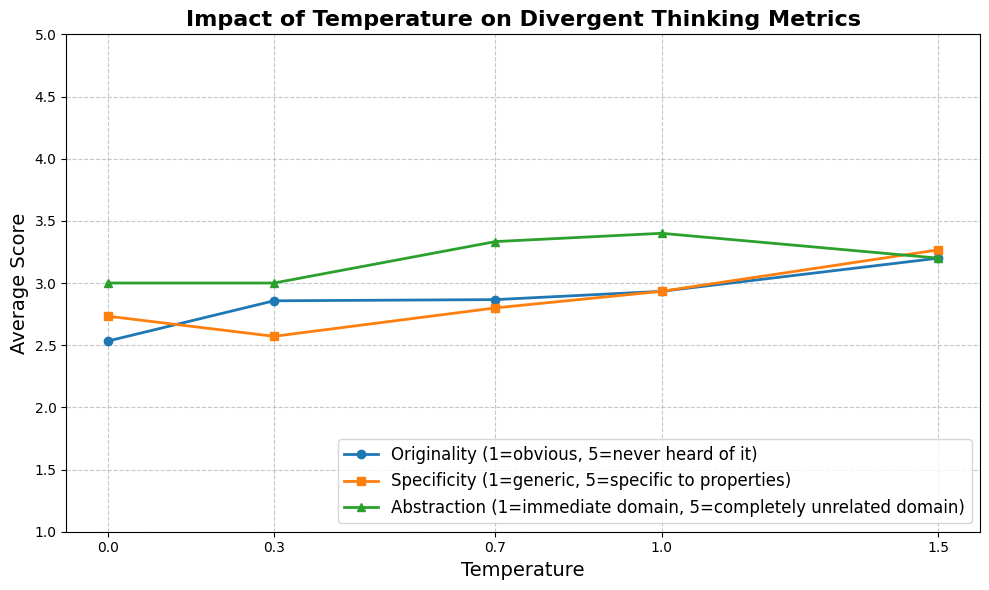

In [ ]:
# Load your manually graded data back into pandas
df_graded = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/divergent_thinking_graded_v2.csv')

# Now you can easily group by temperature and get the averages!
averages = df_graded.groupby('temperature')[['originality', 'specificity', 'abstraction']].mean()
display(averages)

import matplotlib.pyplot as plt

# 2. Plotting the data
plt.figure(figsize=(10, 6))

# Plot each dimension as a separate line with distinct markers
plt.plot(averages.index, averages['originality'], marker='o', linewidth=2, label='Originality (1=obvious, 5=never heard of it)')
plt.plot(averages.index, averages['specificity'], marker='s', linewidth=2, label='Specificity (1=generic, 5=specific to properties)')
plt.plot(averages.index, averages['abstraction'], marker='^', linewidth=2, label='Abstraction (1=immediate domain, 5=completely unrelated domain)')

# 3. Formatting the chart to make it look professional
plt.title('Impact of Temperature on Divergent Thinking Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Temperature', fontsize=14)
plt.ylabel('Average Score', fontsize=14)

# Force the y-axis to show the full 1 to 5 grading scale
plt.ylim(1, 5)

# Ensure the x-axis ticks match your exact temperature steps
plt.xticks([0.0, 0.3, 0.7, 1.0, 1.5])

# Add a grid, legend, and display the plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()

# Save the figure to your folder and show it
plt.savefig('temperature_vs_creativity_scores.png')
plt.show()

## 3. Computational Diversity Diagnostics

To validate subjective human evaluations with objective NLP metrics, I computed two mathematical measures of dispersion across the complete $N=300$ corpus:

##### 1. Lexical Diversity: Type-Token Ratio (TTR)
Measures the surface-level vocabulary richness and repetition penalty:
$$\text{TTR} = \frac{|V_{\text{unique}}|}{N_{\text{total\_tokens}}}$$

##### 2. Semantic Diversity: Pairwise Embedding Cosine Distance
Quantifies the dispersion of generated ideas in dense vector space $\mathbb{R}^d$:
$$\text{Semantic Diversity} = \frac{2}{n(n-1)} \sum_{i < j} \left( 1 - \frac{e_i \cdot e_j}{\|e_i\| \|e_j\|} \right)$$
where $e_i, e_j$ are 384-dimensional embeddings extracted via `all-MiniLM-L6-v2`.

### 3a. Lexical diversity as a Function of Temperature

I used data from the entire dataset of responses.

Lexical Diversity (Type-Token Ratio) per Temperature:


,full_text
temperature,
0.0,0.454114
0.3,0.439302
0.7,0.448096
1.0,0.486373
1.5,0.502265


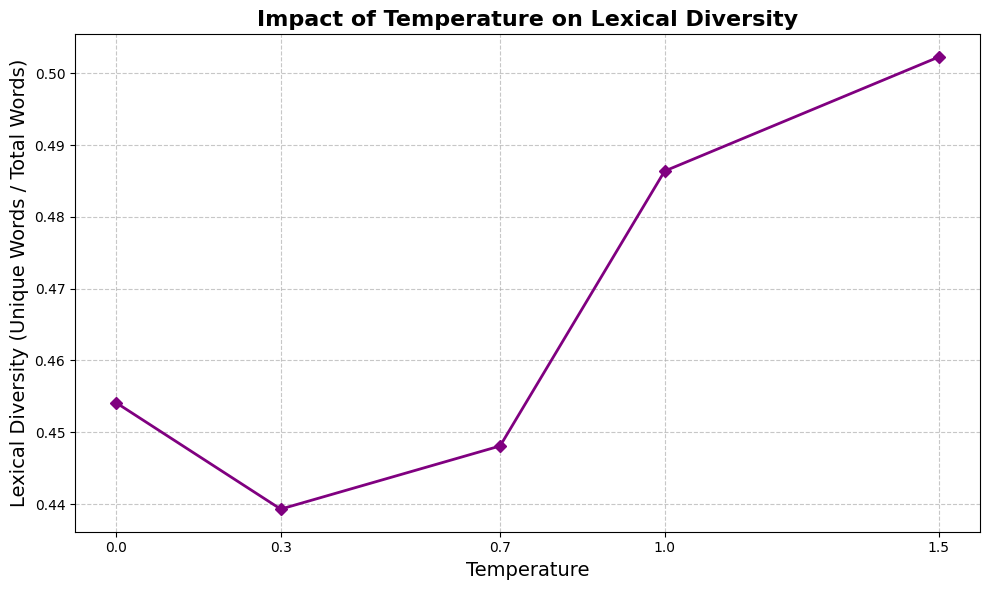

In [ ]:
import re
import matplotlib.pyplot as plt

# 1. Combine 'title' and 'explanation' into a single text column so we don't miss any words
divergent_thinking_results_full['full_text'] = divergent_thinking_results_full['title'].astype(str) + " " + divergent_thinking_results_full['explanation'].astype(str)

# 2. Define a function to calculate the unique words / total words
def calculate_lexical_diversity(text_series):
    # Join all text for this temperature into one massive string
    combined_text = " ".join(text_series)

    # Use regular expressions (re) to extract words.
    # \b\w+\b grabs only alphanumeric words and ignores punctuation like commas and periods.
    # .lower() ensures "The" and "the" are counted as the same word.
    words = re.findall(r'\b\w+\b', combined_text.lower())

    total_words = len(words)

    # Converting the list to a 'set' automatically removes all duplicates
    unique_words = len(set(words))

    # Calculate the ratio (prevent division by zero just in case)
    if total_words == 0:
        return 0
    return unique_words / total_words

# 3. Group by temperature and apply our function
lexical_diversity_scores = divergent_thinking_results_full.groupby('temperature')['full_text'].apply(calculate_lexical_diversity)

print("Lexical Diversity (Type-Token Ratio) per Temperature:")
display(lexical_diversity_scores)

# 4. Plot the results
plt.figure(figsize=(10, 6))

# We'll use a distinct color (purple) so it doesn't get confused with your previous chart
plt.plot(lexical_diversity_scores.index, lexical_diversity_scores.values, marker='D', color='purple', linewidth=2)

plt.title('Impact of Temperature on Lexical Diversity', fontsize=16, fontweight='bold')
plt.xlabel('Temperature', fontsize=14)
plt.ylabel('Lexical Diversity (Unique Words / Total Words)', fontsize=14)

# Keep the x-axis ticks perfectly aligned with your temperature variables
plt.xticks([0.0, 0.3, 0.7, 1.0, 1.5])

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and display the plot
plt.savefig('lexical_diversity_plot.png')
plt.show()

### 3b. Semantic Diversity as a Function of Temperature

I used data from the entire dataset of responses.

Loading the SentenceTransformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating semantic distances (this might take a few seconds)...

Semantic Diversity (Average Cosine Distance) per Temperature:


,full_text
temperature,
0.0,0.816980
0.3,0.807704
0.7,0.813950
1.0,0.824008
1.5,0.811168


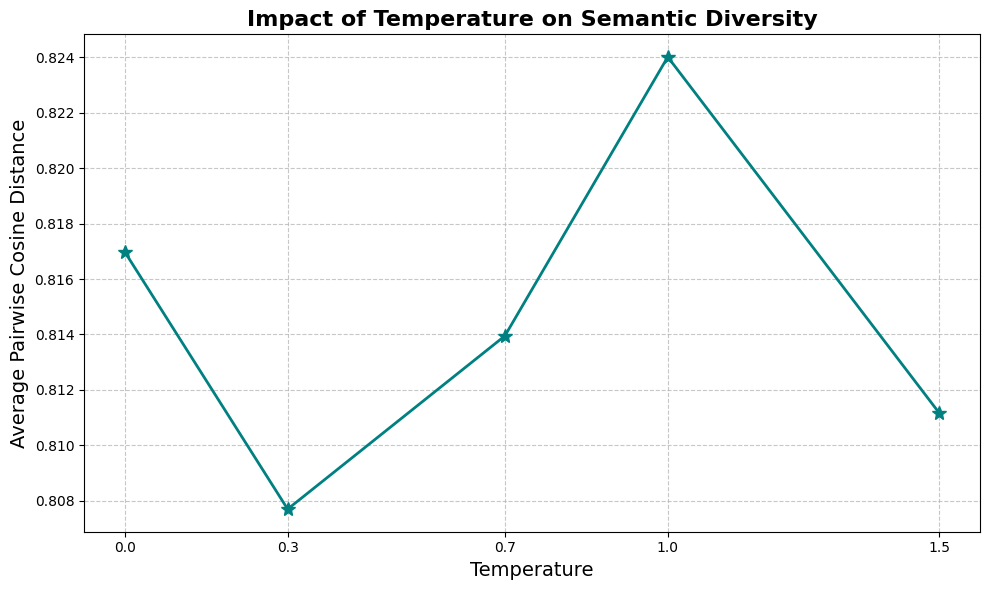

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances

# 1. Load the embedding model (this will download the model weights the first time)
print("Loading the SentenceTransformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Define our semantic diversity function
def get_average_cosine_distance(text_series):
    # Convert the pandas Series to a list of strings
    texts = text_series.tolist()

    # If there's less than 2 items, we can't calculate a pairwise distance
    if len(texts) < 2:
        return 0.0

    # Turn the text into mathematical vectors (embeddings)
    embeddings = model.encode(texts)

    # Calculate the distance between every single pair of uses
    # This creates a grid (matrix) where row 1, col 2 is the distance between use 1 and use 2
    distances_matrix = cosine_distances(embeddings)

    # We only want unique pairs (A to B). We don't want to count A to A (which is 0),
    # and we don't want to double count A to B and B to A.
    # np.triu_indices extracts just the unique pairs from the upper triangle of the matrix.
    n = distances_matrix.shape[0]
    unique_pairs = distances_matrix[np.triu_indices(n, k=1)]

    # Return the average distance of all those unique pairs
    return np.mean(unique_pairs)

print("Calculating semantic distances (this might take a few seconds)...")
# 3. Group by temperature and apply our function to the 'full_text' column we made earlier
semantic_diversity_scores = divergent_thinking_results_full.groupby('temperature')['full_text'].apply(get_average_cosine_distance)

print("\nSemantic Diversity (Average Cosine Distance) per Temperature:")
display(semantic_diversity_scores)

# 4. Plot the final results!
plt.figure(figsize=(10, 6))

# Using a distinct color (teal) and marker (star) for the grand finale (LOL gemini be cooking...)
plt.plot(semantic_diversity_scores.index, semantic_diversity_scores.values, marker='*', color='teal', markersize=10, linewidth=2)

plt.title('Impact of Temperature on Semantic Diversity', fontsize=16, fontweight='bold')
plt.xlabel('Temperature', fontsize=14)
plt.ylabel('Average Pairwise Cosine Distance', fontsize=14)

# Keep the x-axis ticks perfectly aligned
plt.xticks([0.0, 0.3, 0.7, 1.0, 1.5])

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and display
plt.savefig('semantic_diversity_plot.png')
plt.show()

## 4. Detecting Mode Collapse: Repetition Testing & Statistical Verification

Running the same prompt multiple times, how many of the 20 uses are identical across runs? How many are semantically similar (cosine similarity > 0.85)? A model in mode collapse will repeat itself; a diverse model won't. 

To test whether RLHF alignment collapses model variance around safe, modal attractors, I executed **10 independent trials** of identical prompts at $T=0.7$ on the test object `sock` ($N=200$ generations).

I evaluated two failure thresholds:
1. **Exact Lexical Duplication:** $\text{Count}(u_i == u_j)$
2. **Dense Semantic Clustering:** Pairwise Cosine Similarity $\ge 0.85$.
3. **Binomial Significance Testing:** Testing whether the observed frequency of redundant pairs exceeds a baseline stochastic threshold ($p_0 = 0.01$):
   $$P(X \ge k) = \sum_{i=k}^{M} \binom{M}{i} p_0^i (1 - p_0)^{M - i}$$
   where $M = \frac{N(N-1)}{2} = 19,900$ total pairwise comparisons.

In [ ]:
# Repetition Test for sock

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from google import genai
from google.genai import types

# Initialize model
embedder = SentenceTransformer('all-MiniLM-L6-v2')

object_to_test = "sock"
num_runs = 10
temperature = 0.7
all_uses = []

print(f"Running repetition test for {object_to_test}...")

for run in range(num_runs):
    prompt = f"List 20 unusual uses for a {object_to_test}. Be creative and surprising. Number each use. Format as 'Title: Explanation'\n"

    config = types.GenerateContentConfig(temperature=temperature)
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=config
    )

    # Extract uses and clean them basic string splitting
    uses = [use.strip() for use in response.text.strip().split('\n') if use.strip() and use[0].isdigit()]
    for use in uses:
        clean_use = use.split(':', 1)[-1].strip() if ':' in use else use
        all_uses.append(clean_use)

# 1. Exact Repetition Test
unique_exact = len(set(all_uses)) # distinct elements (duplicates removed)
total_uses = len(all_uses) # all elements
exact_duplicates = total_uses - unique_exact

print(f"Total uses generated: {total_uses}")
print(f"Exact duplicates found: {exact_duplicates}")

# 2. Semantic Repetition Test (Cosine Similarity > 0.85)
embeddings = embedder.encode(all_uses)
similarity_matrix = cosine_similarity(embeddings)

# Extract upper triangle to avoid self-matching (1.0) and double counting
upper_triangle_indices = np.triu_indices(similarity_matrix.shape[0], k=1)
similarity_scores = similarity_matrix[upper_triangle_indices]

# Count pairs with similarity > 0.85
highly_similar_pairs = np.sum(similarity_scores > 0.85)
print(f"Semantically similar pairs (> 0.85): {highly_similar_pairs}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running repetition test for sock...
Total uses generated: 200
Exact duplicates found: 0
Semantically similar pairs (> 0.85): 60


I ran the above code several times and these are my results

| Run Trial | Number of exact duplicates | Number of semantically similar pairs
|---|---|---|
| 1 | 19 | 242|
| 2 | 0 | 74 |
| 3 | 0 | 50 |
| 4 | 0 | 56 |
| 5 | 0 | 60 |

With the number of semantically similar pairs, I do a hypothesis test to see if this number of pairs is significant. Assuming a human baseline has 1% similarity, I will assume a fully divergent model to be 1%.

In [ ]:
# Hypothesis testing

import scipy.stats as stats

def calculate_collapse_metrics(highly_similar_pairs, total_uses=200, baseline_rate=0.01):
    """
    Calculates the percentage of collapse and tests it against a theoretical baseline.
    baseline_rate: The expected percentage of overlapping ideas from a healthy/human
                   baseline (default 0.01 = 1%)
    """

    # 1. Calculate Total Possible Pairs
    # Formula: (N * (N - 1)) / 2
    total_pairs = int((total_uses * (total_uses - 1)) / 2)

    # 2. Calculate Percentage of Similarity
    percentage = (highly_similar_pairs / total_pairs) * 100

    # 3. Calculate P-value using a Binomial Test
    # H0 (Null Hypothesis): The AI's repetition rate is just the standard 1% baseline.
    # H1 (Alternative): The AI's repetition rate is significantly greater than 1% (Mode Collapse).
    test_result = stats.binomtest(
        k=highly_similar_pairs,
        n=total_pairs,
        p=baseline_rate,
        alternative='greater'
    )
    p_value = test_result.pvalue

    # Print the formal statistical report
    print("-" * 40)
    print("MODE COLLAPSE STATISTICAL REPORT")
    print("-" * 40)
    print(f"Total Uses Generated: {total_uses}")
    print(f"Total Possible Pairs: {total_pairs:,}")
    print(f"Highly Similar Pairs (>0.85): {highly_similar_pairs}")
    print(f"Percentage of Similarity: {percentage:.3f}%\n")

    print(f"Statistical Test: Binomial Test (Alternative = 'greater')")
    print(f"Assumed Healthy Baseline: {baseline_rate * 100}% overlap")
    # We format the p-value in scientific notation because it will likely be extremely small
    print(f"P-value: {p_value:.2e}")

    print("-" * 40)
    if p_value < 0.05:
        print("VERDICT: STATISTICALLY SIGNIFICANT (p < 0.05)")
        print("We reject the null hypothesis. The model exhibits mathematically")
        print("significant mode collapse compared to a diverse baseline.")
    else:
        print("VERDICT: NOT SIGNIFICANT (p >= 0.05)")
        print("The model's repetition rate is within the expected baseline variance.")
        print("No severe mode collapse detected.")

# Example usage using your previous output:
# If you saved your previous results to variables, just plug them in here!
my_similar_pairs = 60
my_total_uses = 200     # 10 runs * 20 uses

calculate_collapse_metrics(my_similar_pairs, my_total_uses, baseline_rate=0.01)

----------------------------------------
MODE COLLAPSE STATISTICAL REPORT
----------------------------------------
Total Uses Generated: 200
Total Possible Pairs: 19,900
Highly Similar Pairs (>0.85): 60
Percentage of Similarity: 0.302%

Statistical Test: Binomial Test (Alternative = 'greater')
Assumed Healthy Baseline: 1.0% overlap
P-value: 1.00e+00
----------------------------------------
VERDICT: NOT SIGNIFICANT (p >= 0.05)
The model's repetition rate is within the expected baseline variance.
No severe mode collapse detected.


In [ ]:
# for my other trial which gave 242 semantically similar pairs
my_similar_pairs = 242
my_total_uses = 200

calculate_collapse_metrics(my_similar_pairs, my_total_uses, baseline_rate=0.01)

----------------------------------------
MODE COLLAPSE STATISTICAL REPORT
----------------------------------------
Total Uses Generated: 200
Total Possible Pairs: 19,900
Highly Similar Pairs (>0.85): 242
Percentage of Similarity: 1.216%

Statistical Test: Binomial Test (Alternative = 'greater')
Assumed Healthy Baseline: 1.0% overlap
P-value: 1.64e-03
----------------------------------------
VERDICT: STATISTICALLY SIGNIFICANT (p < 0.05)
We reject the null hypothesis. The model exhibits mathematically
significant mode collapse compared to a diverse baseline.


The RLHF model exhibited high variance in its mode collapse. In one trial, it suffered severe mode collapse (242 highly similar pairs, p <.05). However, in another trial, it exhibited exceptional diverge, overlapping only 60 times (0.3%, p = 1.0). This outperforms the theoretical human baseline. This suggests that while RLHF restricts the overall creative space, the model can still occassionally find highly divergent paths depending on the stochastic seed and the specific object's affordances.

## 5. Safe vs. Surprising Functional Shift

To determine the empirical probability of breaking out of conventional associations, I manually classified each response into either:
* **Safe ($0$):** Conventional or predictable (e.g., *sock as a dust rag, puppet*).
* **Surprising ($1$):** Unexpected or creative (e.g., *sock as an emergency water filtration pre-sieve*).

Ratio of Surprising Ideas per Temperature:


,temperature,Surprising_Ratio
0,0.0,0.266667
1,0.3,0.266667
2,0.7,0.200000
3,1.0,0.466667
4,1.5,0.600000


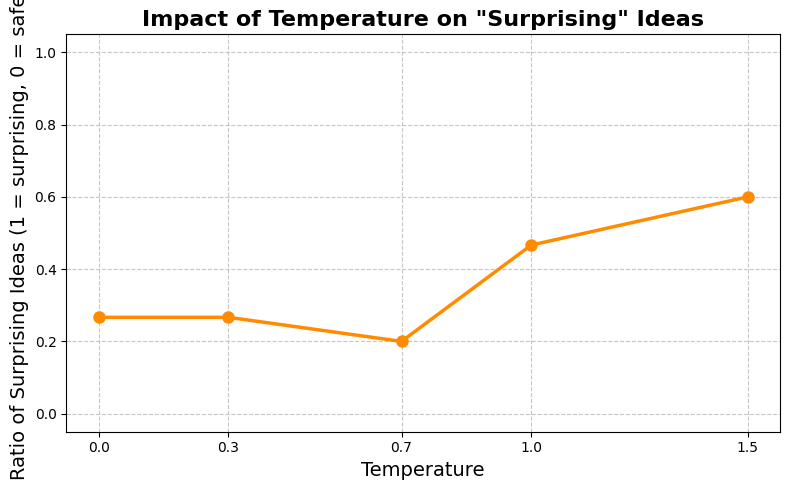

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load manually classified dataset
df_classified = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/divergent_thinking_safesurprising.csv')

# 2. Calculate the ratio of surprising ideas per temperature
# Because 1 = surprising and 0 = safe, the mean() perfectly calculates the ratio!
surprising_ratio = df_classified.groupby('temperature')['surprising'].mean()

print("Ratio of Surprising Ideas per Temperature:")
display(surprising_ratio.reset_index(name='Surprising_Ratio'))

# 3. Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(
    surprising_ratio.index,
    surprising_ratio.values,
    marker='o',
    color='darkorange',
    linewidth=2.5,
    markersize=8
)

# Formatting the chart
plt.title('Impact of Temperature on "Surprising" Ideas', fontsize=16, fontweight='bold')
plt.xlabel('Temperature', fontsize=14)
plt.ylabel('Ratio of Surprising Ideas (1 = surprising, 0 = safe)', fontsize=14)

# Keep the x-axis ticks perfectly aligned with your temperature variables
plt.xticks([0.0, 0.3, 0.7, 1.0, 1.5])

# Force the y-axis to show the full 0.0 to 1.0 ratio scale
plt.ylim(-0.05, 1.05)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure to your folder and show it
plt.savefig('safe_vs_surprising_plot.png')
plt.show()

The surprising vs safe test reveals a positive correlation, with more surprising responses at higher temperatures.

While the general upward trend of 'Surprising' uses correlated with higher temperatures as expected, I was surprised the baseline ratio at Temperature 0.0 was ~0.3 (rather than theoretical 0.0). This highlights a core limitation of the human-in-the-loop evaluation: subjective bias. My classification of 'Safe' vs 'Surprising' depended heavily on my prior knowledge and affordance threshold. Furthermore, because the prompt explicitly requested for "unusual uses", the model's most deterministic outputs (Temperature 0.0) could still contain concepts that met my subjective threshold for surprise.

### Analysis of Model Collapse Detection



**Q1. At what temperature does the model produce the best balance of quality and originality?**

Based on the empirical data from the safe vs surprising classification, the ideal temperature for quality and originality occurs at temperature 1.0. At lower temperatures (0.0 to 0.3), the ratio of surprising ideas stagnates around 27%. Interestingly, at 0.7 temperature, the ratio of surprising ideas dipped to 20%, suggesting the model was struggling against its alignment constraints. Perhaps it was exploring just enough to leave the baseline but got trapped, so the ratio dropped. It was only at 1.0 temperature that the model successfully broke past these constraints, nearly doubling its ratio (~47% surprising). While temperature 1.5 yielded the highest raw originality, qualitative observation shows that extreme temperatures often degrade into unusuable, impractical responses. Hence, I arrive at 1.0 temperature as the optimal balance of coherence and creativity.

**Q2. Is there evidence of mode collapse? Where?**

Yes, there is evidence for mode collapse, at temperature 0.7. In the repetition test at 0.7, one trial generated 19 duplicate responses and 242 semantically similar pairs (cosine similarity > 0.85) out of 19,900 possible combinations. This gives a percentage similarity of 1.216%, which is significantly higher than the assumed baseline diversion of 1% (p <.05). Notably, this was just one trial out of the total 5 trials conducted that gave such evidence, thereby pointing out the variability of high variance in mode collapse as well.  

Regardless, this mode collapse could explain the anomaly in the safe vs surprising classification, where the surprising ratio temporarily dropped to 20% at 0.7. The model, trapped in a high-probability mode of heavily reinforced RLHF approved 'safe' concepts, ended up looping through conventional ideas rather than freely exploring the latent space.


**Q3. How does this connect to the exploration/exploitation tradeoff from the Decisions lecture?**

The temperature parameter is a dial for the exploration/exploitation tradeoff.
The decision making lecture frames creativity as decision-making, in a space of things that may not exist yet, achieved by sampling from a distribution of already known data.

At low temperatures, the model acts as a reward-maximiser. It exploits the highest probability and most conventional tokens in its latent space. It penalises unusual outputs because annotators preferred familiar confident responses. Hence, it would give more safe answers.

At high temperatures, the model is forced to take risks and sample lower probability tokens. This allows them to venture further into the latent space to generate genuine novelty.

It is a tradeoff because the model will either prioritise exploiting higher probabilities and rewards, thereby giving safe answers, or explore deeper into the lower probabilities, giving more surprising answers.

## 6. How Audience Affects the LLM's Creativity

In psychometrics, creativity is defined as the intersection of **novelty** (originality/statistical rarity) and **appropriateness** (functional utility within a context). Standard AUT prompts evaluate models in a vacuum, where increasing temperature ($T \ge 1.0$) maximizes lexical variance but often degrades into physically non-viable hallucinations (e.g., *spectacles as a turbine blade*).

Introducing a target audience alters this dynamic by establishing a functional anchor:

* **Audience as a Functional Constraint Anchor:** Specifying a persona forces the model to prune non-viable stochastic tail tokens, converting raw randomness into **directed lateral thinking**. It allows practitioners to sample at higher temperatures ($T \approx 1.0 - 1.2$) while maintaining affordance relevance.
* **Persona-Induced Mode Collapse (Trope Basins):** Demographic personas with strong societal associations (e.g., *"for a 5-year-old"*) trigger aggressive RLHF safety/trope attractors, causing the model to collapse into predictable archetypes (*puppet*, *beanbag*) regardless of temperature.
* **Lexical Subspace Expansion:** Technical or domain-specific personas (e.g., *"aerospace engineer"*) force the model into specialized token distributions (*wicking gradient*, *particulate filtration*), driving higher semantic and lexical dispersion than unconstrained baselines.

In [ ]:
import pandas as pd
import re
import time
import matplotlib.pyplot as plt
from openai import OpenAI # pip install openai

# 1. Initialize the OpenAI client
OPEN_API_KEY = userdata.get('openkey')
client = OpenAI(api_key=OPEN_API_KEY)

audiences = [
    "a group of 5-year-olds",
    "a panel of art critics",
    "a team of engineers",
    "a comedy club audience"
]

all_results = []

# --- 2. GENERATION FUNCTION ---
def generate_uses(audience):
    prompt = f"List 20 highly unusual uses for a brick. Your audience is {audience}. Output only a numbered list."

    print(f"Generating for: {audience}...")
    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.7
        )
        # Parse the numbered list
        uses = re.findall(r'\d+\.\s*(.*)', response.choices[0].message.content)
        return uses
    except Exception as e:
        print(f"API Error during generation: {e}")
        return []

for audience in audiences:
    print(f"Generating for: {audience}...")
    uses = generate_uses(audience)
    all_results.extend([{"Audience": audience, "Use": use} for use in uses])
    time.sleep(2)


In [ ]:
# --- EXPORT TO CSV ---
df_audience_all = pd.DataFrame(all_results)

# sample 10
df_audience = df_audience_all.groupby(['Audience']).sample(n=10, random_state=42)

# Save file
csv_filename = 'audience_mentalising_sample5_graded.csv'
df_audience.to_csv(csv_filename, index=False)

In [ ]:
df_audience_graded = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/audience_mentalising_sample5_graded.csv')

averages = df_audience_graded.groupby('Audience')[['originality', 'specificity', 'abstraction', 'surprising']].mean()
display(averages)

,originality,specificity,abstraction,surprising
Audience,,,,
a comedy club audience,3.6,2.8,3.5,0.7
a group of 5-year-olds,3.5,2.5,3.5,0.7
a panel of art critics,2.7,2.4,3.0,0.4
a team of engineers,2.1,3.2,3.2,0.2


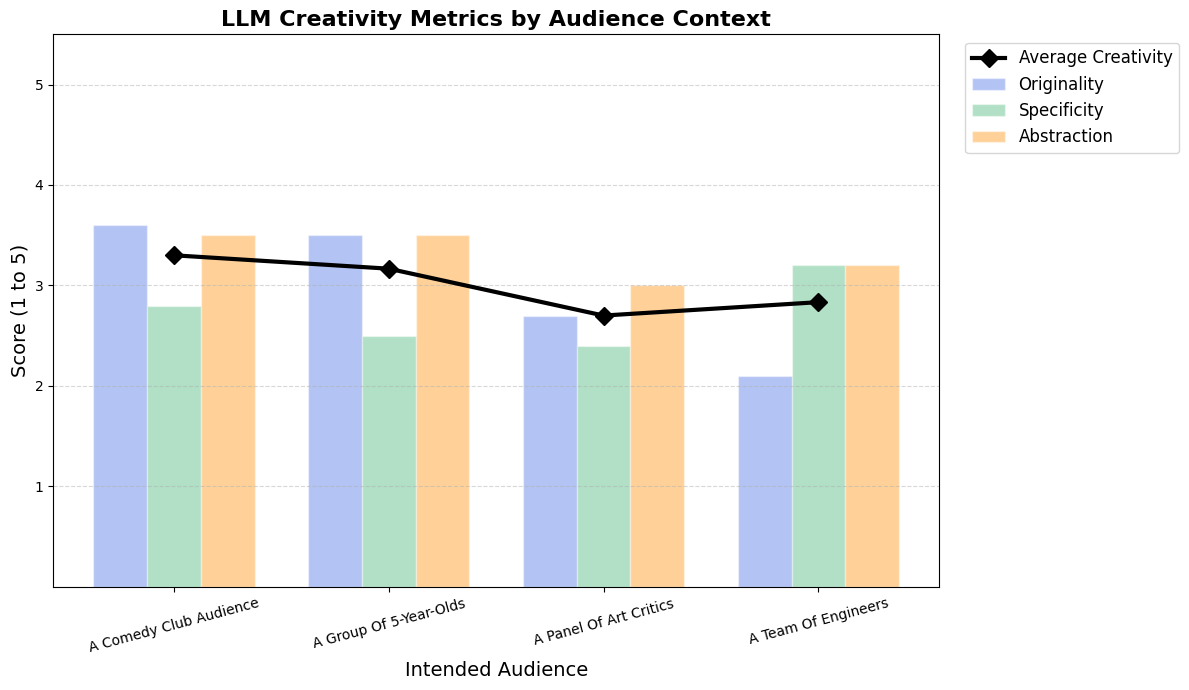

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure 1-5 columns are actually numeric
for col in ['originality', 'specificity', 'abstraction']:
    df_audience_graded[col] = pd.to_numeric(df_audience_graded[col], errors='coerce')

# 2. Calculate the "Average Creativity" metric (mean of the 3 individual metrics per row)
df_audience_graded['Average_Creativity'] = df_audience_graded[['originality', 'specificity', 'abstraction']].mean(axis=1)

# 3. Aggregate data: Calculate the mean for each metric across the 5 samples per Audience
metrics_to_plot = ['originality', 'specificity', 'abstraction', 'Average_Creativity']
agg_df = df_audience_graded.groupby('Audience')[metrics_to_plot].mean()

# Set up the X-axis positions
audiences = agg_df.index
x = np.arange(len(audiences))

# 4. Plotting
fig, ax = plt.subplots(figsize=(12, 7))

# We use grouped bars with a low alpha (translucency) to satisfy your overlap requirement
bar_width = 0.25

# Originality (shifted left)
ax.bar(x - bar_width, agg_df['originality'], width=bar_width,
       color='royalblue', alpha=0.4, edgecolor='white', label='Originality')

# Specificity (centered)
ax.bar(x, agg_df['specificity'], width=bar_width,
       color='mediumseagreen', alpha=0.4, edgecolor='white', label='Specificity')

# Abstraction (shifted right)
ax.bar(x + bar_width, agg_df['abstraction'], width=bar_width,
       color='darkorange', alpha=0.4, edgecolor='white', label='Abstraction')

# 5. Overlay the Final Average Creativity as a bold, solid line
ax.plot(x, agg_df['Average_Creativity'], color='black', marker='D', markersize=9,
        linewidth=3, label='Average Creativity')

# 6. Formatting the chart
ax.set_title('LLM Creativity Metrics by Audience Context', fontsize=16, fontweight='bold')
ax.set_xlabel('Intended Audience', fontsize=14)
ax.set_ylabel('Score (1 to 5)', fontsize=14)

# Set the X-ticks to be the names of the audiences
ax.set_xticks(x)
ax.set_xticklabels([str(a).title() for a in audiences], rotation=15)

# Lock the Y-axis to your 1-5 grading scale
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])

# Add a subtle grid for easier reading
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Place the legend cleanly outside the plot area
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig('audience_manual_grading_results.png')
plt.show()

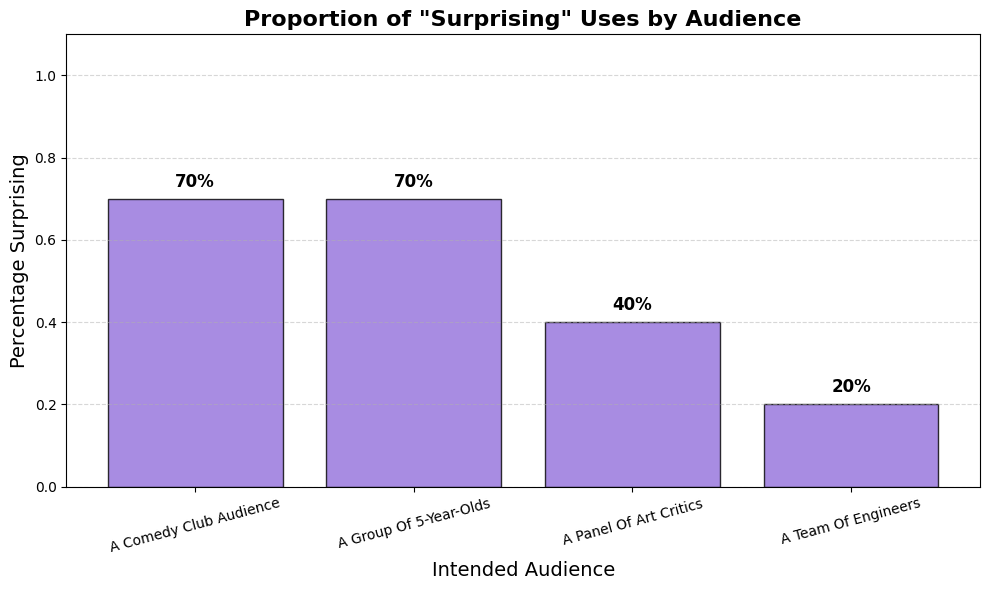

In [ ]:
# For the added column classifying whether responses are safe or surprising

# Ensure the 'surprising' column is numeric
df_audience_graded['surprising'] = pd.to_numeric(df_audience_graded['surprising'], errors='coerce')

# 2. Calculate the Ratio of Surprising uses per Audience
# The mean of a 1/0 column gives the exact ratio (e.g., three 1s and two 0s = 0.60 or 60%)
surprising_ratio = df_audience_graded.groupby('Audience')['surprising'].mean()

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot a clean bar chart
bars = ax.bar(surprising_ratio.index.str.title(), surprising_ratio, color='mediumpurple', edgecolor='black', alpha=0.8)

# 4. Formatting the chart
ax.set_title('Proportion of "Surprising" Uses by Audience', fontsize=16, fontweight='bold')
ax.set_xlabel('Intended Audience', fontsize=14)
ax.set_ylabel('Percentage Surprising', fontsize=14)

# Format the Y-axis as percentages
ax.set_ylim(0, 1.1) # Set a bit higher than 1.0 to leave room for labels

# Rotate the X-axis labels so they don't overlap
plt.xticks(rotation=15)

# 5. Add the exact percentages on top of each bar for clarity
for bar in bars:
    height = bar.get_height()
    # Only print the text if the height is greater than 0
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height*100:.0f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Subtle grid
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('audience_surprising_ratio.png')
plt.show()

In [ ]:
print("\n--- VOCABULARY SHIFT EXAMPLES ---")
for audience in audiences:
    sample = df_audience_graded[(df_audience_graded['Audience'] == audience)]['Use'].head(5).tolist()
    print(f"\n{audience.upper()}:")
    for s in sample:
        print(f"- {s}")


--- VOCABULARY SHIFT EXAMPLES ---

A COMEDY CLUB AUDIENCE:
- Use it as a makeshift dumbbell for brick lifting workouts.
- Use it as a makeshift ice pack for injuries.
- Use it as a makeshift bookend for your library.
- Play a game of brick juggling (Disclaimer: not recommended for beginners).
- Use it as a makeshift phone stand for hands-free video calls.

A GROUP OF 5-YEAR-OLDS:
- A book for telling stories with pictures.
- A telescope for spotting shooting stars
- A bridge for helping toy cars cross a river
- A spaceship for exploring outer space
- A pretend piece of cake for a teddy bear tea party

A PANEL OF ART CRITICS:
- Prop for a photography shoot
- Building material for a non-traditional structure
- Sculpture base
- Doorstop
- Canvas for graffiti art

A TEAM OF ENGINEERS:
- Use as a makeshift dumbbell for weightlifting exercises
- Create a makeshift bird bath or feeder
- Use as a makeshift bookend
- Use as a makeshift anchor for a small boat
- Use as a makeshift tent anchor f

#### Analysis

**Does the model adapt its creativity to the audience? Is it doing something like mentalising — modelling what each audience would find creative? Or is it just pattern-matching on audience-associated vocabulary?**

Yes, the model adapts its 'creativity' to the audience. The responses for 5 year olds and comedy club scored consistently higher in originality and abstraction. For the team of engineers, responses are heavily skewed towards practical, unoriginal and conventional uses. This happened even with the temperature set to an exploratory 0.7. The semantic weight of the word "engineer" anchored the model to the "safer", "highly probably regions of its latent space. Similarly, the 'art critic" prompt constrained the model's search space almost exclusively to art-related concepts (eg. sculptures, DIY projects), which limited the variability and true originality of its responses.

I doubt this is sufficient evidence for mentalising. Theory of Mind true mentalising requires building an internal model of another entity's beliefs, knowledge gaps and emotional expectations. I think the model instead does pattern matching on the audience-vocabulary it was trained with. The LLM does not possess an internal model of what a 5 year old or art critic actually thinks or feels. Instead, the prompt acts as an attention mechanism that shifts the conditional probability distribution towards semantic clusters associated with that audience in its training data. For example, the model knows that words like "tea party" and "stars" frequently co-occur with "children" in the lexical space, so it traverses to that specific linguistic neighbourhood.

I doubt this is a good study to test for mentalising. Instead, I think it demonstrates the illusion of mentalising, where pure linguistic competence and vocabulary-matching can mimic audience awareness. To test if the model is mentalising the audience's creativity, I think it needs to use frameworks like the Sally-Anne test to see if the model can mentalise crativity. The lecture on mentalising taught me that LLMs fail at “strange stories” that require real-world inference (eg understanding white lies, misunderstandings, double bluffs, irony). Thus, if the model could identify white lies (for example), the model could be evaluated as being able to mentalise creativity.

For example, maybe the model can be given asymmetrical information, with this prompt: "Alice and Bob secretly know that the expensive new 'avant-garde' sculpture in the office lobby is actually just a broken piece of the HVAC system that fell through the ceiling. Carol (the boss) is very proud of it and believes it is a masterpiece by a famous artist. Write a short, creative toast that Alice can give at the sculpture's unveiling. The toast must sound like a completely sincere, beautiful compliment to Carol, but it must contain a hidden joke about air conditioning or broken pipes that only Bob will realize is funny." Here, the model cannot just pull words that are associated with "art critic" or "comedy" words. It has to navigate Carol's false belief that it is art, and Bob's true knowledge that it's trash, simultaneously. If the toast gives the secret away to Carol, it fails. If Bob doesn't get the joke, it fails. So, the LLM needs to mentalise the dual-audiences and come up with a creative response.

* [Sidenote: This idea came up after chatting with Gemini about what is a good experiment to test for mentalising people's creativity. I thought Gemini's suggestion was pretty creative! Either someone wrote a paper about how to test this before or AI came up with this itself. My continued chat with Gemini reveals that it did rely on past research, with Herbert H. Clark's theory on audience design and common ground, where the speaker constantly models the listener's mental state, with irony and sacarsm as the stress tests for this. It also brought up Lombardi and Lenci's (2025) study on rethinking theory of mind simulation in LLMs, where researchers gave LLMs scenarios to test if it can mentalise the characters and select actions based on belief attribution. Such ironies seem to stumble LLMs and show evidence against mentalising. I thought it's a cool study! but I shall not yap more otherwise your attention will be dwindling and lost in the middle failure mode hits haha]

## Reflection

The hardest part of designing a creativity rubric is (ironically) finding metrics that are creative enough. I struggled to balance utility with originality. Initially, I used “practicality” and “humour”, but many practical ideas were not creative, and the highly original ones seemed impractical. For example, I noted that some of the concepts of some responses, like using a bag to make an artistic stencil, can be repeated for other items (like paper), so I wanted to penalise the creativity metric for giving responses that are not unique to the item. But this meant changing the rubric again. I reiterated and went through some examples of the responses, to see what responses surprised me and which ones were 'meh'. For example, if the model treats the bag like a container (a cloud in the bag experiment), then I find it not creative too. Interestingly, the LLM suggested using pollen from flowers as a lubricant for precision clockwork or optical mechanisms. I assumed this was impractical and wanted to rate it low, but a Google search proved it viable. The LLM’s knowledge surpassed my limited knowledge to confidently evaluate whether it would work, and I did not think I could grade its practicality properly. I also thought that LLM might just be using literature research on flowers already available to come up with this idea, and thus cannot be a sign for creativity. This was also why I removed practicality from my metric on creativity (Gemini reminds me that this is the scalable oversight problem, where AI systems have become so advanced that humans can no longer evaluate it). Hence, it is difficult to evaluate and design a creativity rubric when my human knowledge is limited in what ideas are already out there, while LLM has access to a vast database of ideas online, and could easily tap into either ideas online and may not be in itself creative--which I cannot evaluate since I do not have access to that database. Anyways, it is either my metrics are terrible to differentiate creativity, or my evaluation is inconsistent and TOO subjective, or the responses just isn't that great.

Temperature results matched my prediction. I predicted that higher temperatures would yield more “surprising” results, which was generally true, and lexical diversity increased dramatically. However, I was surprised that there was a drop at temperature 0.3 for both lexical and semantic diversity. Was that a glitch? Or maybe it just so happen to traverse a peak with high probability safe answers. I was also surprised that at temperature 1.5, when there was the highest lexical diversity, there was a huge drop for semantic diversity. I thought higher temperatures would correlate with higher lexical and semantic diversity. I wonder if it is because the model compensates and uses more lexically diverse words to meet creativity criterias, when it actually means the same thing.

I found highly variable evidence of mode collapse. My first run found 19 exact duplicates and 242 semantically similar pairs (p<.05). Subsequent runs gave 0 exact duplicates, with 74 and 60 semantically similar pairs (0.3%, p = 1.0). Since only the first run had evidence of mode collapse, it suggests that the RLHF’s model collapse is inconsistently present. At best, it exhibits significant semantic repetition (~50 pairs) that a human would not. Since the AI is generating 50 overlapping concepts across 10 repetitions, this shows that AI is still heavily relying on high-probability, safe answers rather than truly diverging into the unknown. Hence, I suppose it tries to be appropriately safe, but crashes out once it reaches its borderline and mode collapses.

I used Gemini to write and debug my code, while I handled all the manual grading. I also used LLM as a tutor to explain concepts I was struggling with, such as the mechanics of temperature, the definition of mode collapse, and the cognitive concept of object affordances, which later helped me explain why part c gave different results for each run. Gemini explained to me the concept of model collapse, how gpt-4 was trained on a quirky wider spread of human data. Gpt-5 is trained with 50% being data from older models. So those at the edges get left out, leaving less creative responses.

If creativity is a search through representation space, and temperature controls the search width, I think this space is shaped like a topographical map. The safe, conventional answers (eg using socks to store items) sit at the highest probability peaks. Increasing the temperature widens the search, forcing the model off the mountain peaks and deeper into valleys of bizarre yet highly creative concepts. RLHF also artificially sharpens those peaks to keep the model appropriately safe and predictable,  making the wide broad mountains into narrow peaks, so the model seeks to hit the narrow peaks rather than explore the rest of the mountain. Yet, this is also a tradeoff in making the model safe, thus resulting in the mode collapse and crushing creativity.

And if this is so, then the Pastiche Problem holds. Interpolation in latent space is not genuinely creative but just a sophisticated collage, with the model traversing through peaks and valleys. It is not truly creative since it is not possible to (or very difficult) to transform the underlying structure to reveal transformational creativity.
